# [캐글] 에일리언 vs 프레데터
https://www.kaggle.com/datasets/pmigdal/alien-vs-predator-images

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pmigdal/alien-vs-predator-images")

print("Path to dataset files:", path)

C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\workspace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 14.1M/14.1M [00:02<00:00, 7.12MB/s]

Extracting files...


Path to dataset files: C:\Users\hurwa\.cache\kagglehub\datasets\pmigdal\alien-vs-predator-images\versions\1


In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
PROJECT_DIR

WindowsPath('C:/LANG_CHAIN_2026/2026-05-19_KDT_lang_chain/workspace/python/14_scikit_learn')

In [11]:
DATA_DIR = PROJECT_DIR / "data" / "alien_vs_predator_images" / "data"

print(f"프로젝트 폴더: {PROJECT_DIR}")
print(f"데이터 폴더: {DATA_DIR}")

프로젝트 폴더: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\workspace\python\14_scikit_learn
데이터 폴더: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\workspace\python\14_scikit_learn\data\alien_vs_predator_images\data


In [12]:
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "validation"

print(f"학습 데이터 폴더: {PROJECT_DIR}")
print(f"검증 데이터 폴더: {VAL_DIR}")

학습 데이터 폴더: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\workspace\python\14_scikit_learn
검증 데이터 폴더: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\workspace\python\14_scikit_learn\data\alien_vs_predator_images\data\validation


# 2. Alexnet 모델 활용

### ※ 이미지넷

이미지넷(ImageNet)은 대규모 이미지 데이터셋으로, 컴퓨터 비전 연구와 딥러닝 모델 학습에 널리 사용됩니다.

2009년 스탠포드 대학의 페이페이 리(Fei-Fei Li) 교수팀이 구축했으며, 약 1,400만 장의 이미지와 22,000개 이상의 카테고리로 구성되어 있습니다.

이 중, 가장 널리 사용되는 ILSVRC(Imagenet Large Scale Visual Recognition Challenge) 버전은 약 1,000개의 클래스와 120만 장의 이미지를 포함합니다.

이미지넷은 모델이 객체를 분류하고 특징을 학습하는 데 필요한 풍부한 데이터와 레이블을 제공하며, ResNet, VGG, Inception 등 여러 혁신적인 모델이 이미지넷 대회를 통해 개발되었습니다.

이 데이터셋은 특히 사전 학습(Transfer Learning)에서 중요한 역할을 하며, 딥러닝 연구의 표준 벤치마크로 자리 잡았습니다.

In [5]:
IMAGE_SIZE = 224

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.224]

### 데이터 증강

- 데이터 증강은 학습 이미지의 모양을 조금씩 바꿔 과적합을 줄이는 방법
- 실제 서비스에서 발생하지 않을 정도로 이미지를 심하게 회전하거나 찌그러뜨리면 오히려 잘못된 특징을 학습할 수 있으므로 주의
- 원본 데이터의 촬영 방향, 배경, 밝기, 객체 크기를 분석하고 실제 운영 환경에서 발생할 수 있는 변화만 증강에 반영

In [6]:
from torchvision import transforms, datasets, models

In [13]:
data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=8, shear=8),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    "validation": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
}

In [14]:
image_datasets = {
    "train": datasets.ImageFolder(
        TRAIN_DIR,
        transform=data_transforms["train"],
    ),
    "validation": datasets.ImageFolder(
        VAL_DIR,
        transform=data_transforms["validation"]
    )
}

In [15]:
class_names = image_datasets["train"].classes
print(class_names)
class_to_idx = image_datasets["train"].class_to_idx
print(class_to_idx)
idx_to_class = {
    idx: name
    for name, idx
    in class_to_idx.items()
}

print(idx_to_class)

['alien', 'predator']
{'alien': 0, 'predator': 1}
{0: 'alien', 1: 'predator'}


In [16]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader

In [17]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cuda


In [19]:
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = DEVICE.type == "cuda"
SEED = 2026

In [21]:
# PyTorch의 난수 생성기를 생성
# 딥러닝 ㅇ슨 랜덤 요소가 굉장히 많음
# (가중치, 데이터 섞기, 데이터 증강, train/val 분리)
# 난수 생성기의 시작값을 고정(재현성)
generator = torch.Generator()
generator.manual_seed(SEED)

In [25]:
dataloaders = {
    "train": DataLoader(
        image_datasets["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=PIN_MEMORY,
        generator=generator,
        persistent_workers=(NUM_WORKERS > 0)
    ),
    "validation": DataLoader(
        image_datasets["validation"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0)
    )
}

In [26]:
images, labels = next(iter(dataloaders["train"]))
print("images batch shape:", images.shape)
print("labels batch shape:", labels.shape)
print("labels dtype:", labels.dtype)

images batch shape: torch.Size([32, 3, 224, 224])
labels batch shape: torch.Size([32])
labels dtype: torch.int64


In [24]:
import matplotlib.pyplot as plt

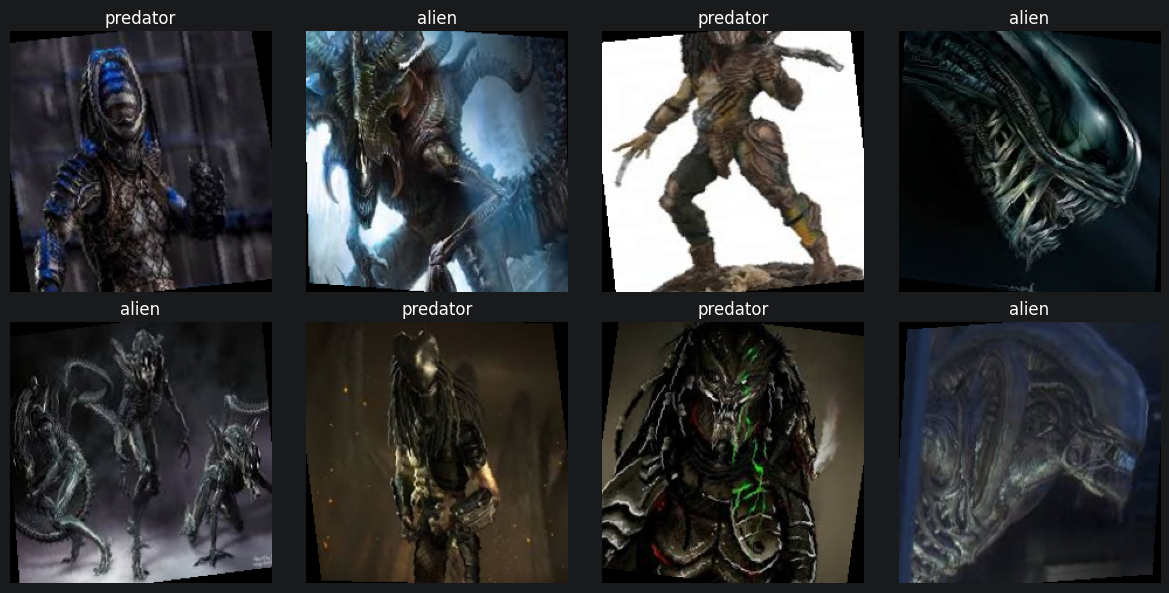

In [39]:
def denormalize_image(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return image.clamp(0, 1)

images, labels = next(iter(dataloaders["train"]))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.flatten(), images[:8], labels[:8]):
    ax.imshow(denormalize_image(image).permute(1, 2, 0))
    ax.set_title(idx_to_class[label.item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

# 3. 전이 학습
전이 학습(Transfer Learning)은 이미 학습된 모델(주로 대규모 데이터셋에서 사전 학습된 딥러닝 모델)을 새로운 문제에 적용하여 학습 시간을 단축하고 성능을 향상시키는 방법입니다.

기존 모델이 학습한 특징(Feature)을 활용해, 새로운 데이터셋에서 모델의 일부(주로 마지막 레이어)만 다시 학습하거나 추가 학습(Fine-tuning)을 진행합니다.

이는 특히 데이터가 적거나 학습 리소스가 제한된 상황에서 효과적이며, 이미지 분류(예: ResNet, VGG), 자연어 처리(예: BERT, GPT) 등 다양한 분야에서 널리 사용됩니다.

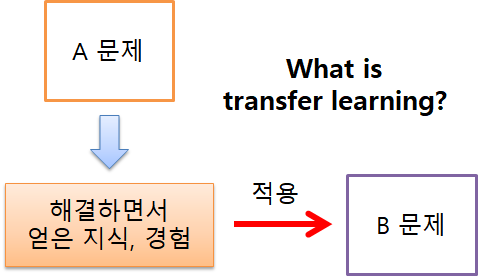

In [40]:
from torchvision.models import AlexNet_Weights

In [42]:
weights = AlexNet_Weights.IMAGENET1K_V1
model = models.alexnet(weights=weights)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\hurwa/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:35<00:00, 6.86MB/s] 


In [43]:
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

### ※ Model Freezing

Model Freezing은 전이 학습(Transfer Learning)에서 사전 학습된 모델의 일부 또는 전체 계층의 가중치를 고정하여 학습되지 않도록 설정하는 기법입니다.

주로 사전 학습된 모델의 초기 계층(Convolutional Layers 등)은 일반적인 특징(예: 가장자리, 패턴)을 학습했으므로 고정하고, 새로운 데이터셋에 특화된 특징을 학습하기 위해 최상위 계층(분류 헤드 등)만 학습합니다.

이 방법은 학습할 가중치의 수를 줄여 계산 비용을 절감하고, 과적합을 방지하며, 데이터가 부족한 상황에서 특히 유용합니다.

필요에 따라, 초기 학습이 끝난 후 일부 계층을 고정 해제(Fine-Tuning)하여 모델을 더 정교하게 조정할 수도 있습니다.

In [46]:
for parameter in model.parameters():
    parameter.requires_grad=False

In [45]:
len([i for i in model.parameters()])

16

In [48]:
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, 1)

In [50]:
model.classifier

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=1, bias=True)
)

In [54]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터 수: {total_params:,}")
print(f"학습 가능한 파라미터 수: {trainable_params:,}")

전체 파라미터 수: 57,007,937
학습 가능한 파라미터 수: 4,097


### BCEWithLogitsLoss
- 이진 분류에서 모델은 확률이 아니라 logit이라는 실수 값을 출력
- 학습 시: BCEWithLogitsLoss()(logits, targets)
- 예측 시: torch.sigmoid(logit)으로 0~1 확률로 변환

> Sigmoid와 BCELoss를 따로 적용하는 방식보다 큰 양수나 음수값에서 수치적으로 더 안정적으로 계산

In [57]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("초기 학습률:", optimizer.param_groups[0]["lr"])

초기 학습률: 0.001


# NVIDIA CUDA GPU를 사용한다면 AMP를 사용함
AMP (Automatic Mixed Precision): 자동으로 혼합 정밀도 연산

FP32에서는 값을 비교적 잘 표현할 수 있지만 FP16에서는 중요한 정보를 잘라서 값이 사라질 수 있음. (underflow)

이 때문에 gradient가 0이 되어버리면 가중치를 제대로 업데이트하지 못할 수 있음



In [ ]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    running_samples = 0

    grad_context = torch.enable_grad() if is_training else torch.inference_mode()

    with grad_context:
        for images, labels in loader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            label = labels.float().unsqueeze(1).to(device, non_blocking=PIN_MEMORY)

            if is_training:
                optimizer.zero_grad()
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                logits = model(images)
                loss = criterion(logits, labels)
            if is_training:

